# HybridNonlinearISAM

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/gtsam/hybrid/doc/HybridNonlinearISAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass  # Not running on Colab, do nothing

`HybridNonlinearISAM` provides an interface for performing incremental nonlinear optimization for hybrid systems using ISAM (Incremental Smoothing and Mapping). It manages an underlying `HybridGaussianISAM` object and handles the relinearization process.

Key concepts:
*   Maintains a full nonlinear factor graph (`HybridNonlinearFactorGraph`) of all factors added so far.
*   Keeps track of the current linearization point (`Values`) and discrete assignment (`DiscreteValues`).
*   Uses an internal `HybridGaussianISAM` object to store the incrementally updated linearized representation (`HybridBayesTree`).
*   The `update` method linearizes new nonlinear factors, incorporates them into the `HybridGaussianISAM`, and updates the estimate.
*   Periodically (controlled by `reorderInterval`), it can perform a full relinearization and reordering of the underlying `HybridGaussianISAM` to maintain accuracy and efficiency.

In [2]:
import gtsam
import numpy as np
import graphviz

from gtsam import (
    HybridNonlinearISAM,
    HybridNonlinearFactorGraph,
    HybridNonlinearFactor,
    PriorFactorPose2,
    BetweenFactorPose2,
    Pose2,
    Point3,
    DecisionTreeFactor,
    Values,
)
from gtsam.symbol_shorthand import X, D

## Initialization

In [3]:
# Initialize HybridNonlinearISAM
# reorderInterval=1 means re-linearize/re-order every update (like batch)
# Set higher (e.g., 10, 100) for true incremental behavior
reorder_interval = 0 # Set to 0 to disable reordering for this example
hisam = HybridNonlinearISAM(reorder_interval)

print(f"Initialized HybridNonlinearISAM with reorderInterval={hisam.reorderInterval()}")

Initialized HybridNonlinearISAM with reorderInterval=0


## Incremental Updates

The `update` method takes new factors (`HybridNonlinearFactorGraph`) and initial estimates (`Values`) for any *new* variables introduced in those factors.

In [4]:
# --- Initial Step (Pose 0 and Mode Prior) ---
step0_graph = HybridNonlinearFactorGraph()
step0_values = Values()

# Add prior on pose X0
prior_noise = gtsam.noiseModel.Diagonal.Sigmas(Point3(0.1, 0.1, 0.05))
step0_graph.add(PriorFactorPose2(X(0), Pose2(0, 0, 0), prior_noise))
step0_values.insert(X(0), Pose2(0.01, 0.01, 0.01)) # Initial estimate for X0

# Add prior on discrete mode D0
dk0 = (D(0), 2) # Binary mode
step0_graph.add(DecisionTreeFactor([dk0], "0.8 0.2")) # P(D0=0)=0.8

print("--- Update 0 ---")
hisam.update(step0_graph, step0_values)
print("ISAM state after update 0:")
# hisam.print() # Printing can be verbose
print(f" Current Lin Point Size: {hisam.getLinearizationPoint().size()}")
current_estimate_0 = hisam.estimate()
print(" Current Estimate 0:")
current_estimate_0.print()


# --- Second Step (Pose 1 and Hybrid Odometry) ---
step1_graph = gtsam.HybridNonlinearFactorGraph()
step1_values = gtsam.Values()

# Add HybridNonlinearFactor for odometry X0->X1
# Mode 0 (Grippy): Smaller noise
noise0 = gtsam.noiseModel.Diagonal.Sigmas(Point3(0.1, 0.1, np.radians(1)))
odom0 = BetweenFactorPose2(X(0), X(1), Pose2(1.0, 0, 0), noise0)
# Mode 1 (Slippery): Larger noise
noise1 = gtsam.noiseModel.Diagonal.Sigmas(Point3(0.5, 0.5, np.radians(10)))
odom1 = BetweenFactorPose2(X(0), X(1), Pose2(1.0, 0, 0), noise1)
hybrid_odom = HybridNonlinearFactor(dk0, [odom0, odom1])
step1_graph.add(hybrid_odom)

# Provide initial estimate for the *new* variable X1
# Use odometry from the current estimate of X0
x0_estimate = current_estimate_0.atPose2(X(0))
x1_initial_guess = x0_estimate.compose(Pose2(1.0, 0, 0))
step1_values.insert(X(1), x1_initial_guess)

print("\n--- Update 1 ---")
hisam.update(step1_graph, step1_values)
print("ISAM state after update 1:")
print(f" Current Lin Point Size: {hisam.getLinearizationPoint().size()}")
current_estimate_1 = hisam.estimate()
print(" Current Estimate 1:")
current_estimate_1.print() # Should be close to (X0=(0,0,0), X1=(1,0,0), D0=0)

--- Update 0 ---
ISAM state after update 0:
 Current Lin Point Size: 1
 Current Estimate 0:
Values with 1 values:
Value x0: (gtsam::Pose2)
(0, 1.73472e-18, -7.77621e-19)


--- Update 1 ---
ISAM state after update 1:
 Current Lin Point Size: 2
 Current Estimate 1:
Values with 2 values:
Value x0: (gtsam::Pose2)
(8.67362e-18, -1.73472e-18, 9.57103e-19)

Value x1: (gtsam::Pose2)
(1.00005, -6.64995e-07, -7.77621e-19)



## Accessing State and Estimates

After updates, you can retrieve the current estimate, the linearization point, the underlying Bayes tree, and the accumulated factors.

In [5]:
# Get the final MAP estimate (calculates from current BayesTree)
final_estimate = hisam.estimate()
print("\nFinal Estimate:")
final_estimate.print()

# Get the current linearization point (used for the last update)
lin_point = hisam.getLinearizationPoint()
print("\nCurrent Linearization Point (Values):")
lin_point.print()

# Get the current discrete assignment (MPE from the last update)
assignment = hisam.assignment()
print("\nCurrent Discrete Assignment:")
print(assignment)


Final Estimate:
Values with 2 values:
Value x0: (gtsam::Pose2)
(8.67362e-18, -1.73472e-18, 9.57103e-19)

Value x1: (gtsam::Pose2)
(1.00005, -6.64995e-07, -7.77621e-19)


Current Linearization Point (Values):
Values with 2 values:
Value x0: (gtsam::Pose2)
(0.01, 0.01, 0.01)

Value x1: (gtsam::Pose2)
(1, 9.57103e-19, -7.77621e-19)


Current Discrete Assignment:
DiscreteValues{7205759403792793600: 0}



Underlying HybridGaussianISAM (HybridBayesTree):


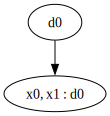

In [6]:
# Get the underlying Gaussian ISAM object (HybridBayesTree)
gaussian_isam = hisam.bayesTree()
print("\nUnderlying HybridGaussianISAM (HybridBayesTree):")
# gaussian_isam.print()
graphviz.Source(gaussian_isam.dot())  # Visualize the BayesTree

## Relinearization and Reordering

If `reorderInterval` is greater than 0, ISAM automatically triggers relinearization and reordering periodically. You can also trigger it manually.

In [7]:
# Manually trigger relinearization (if needed, e.g., after large changes)
print("\nManually triggering relinearize...")
# This relinearizes *all* factors at the current estimate and rebuilds the Bayes tree
try:
    # Note: Direct relinearize might not be exposed or might be handled differently
    # in the nonlinear wrapper compared to ISAM2. Often done within update loop.
    # hisam.reorderRelinearize() # Check if this method exists/works as expected
    print("Manual relinearization might be implicit or handled by ISAM2 patterns.")
    print("Typically happens during update() if counters trigger.")
except Exception as e:
    print(f"Could not call reorderRelinearize: {e}")

# Check counters
print(f"Reorder Counter: {hisam.reorderCounter()}")
print(f"Reorder Interval: {hisam.reorderInterval()}")


Manually triggering relinearize...
Manual relinearization might be implicit or handled by ISAM2 patterns.
Typically happens during update() if counters trigger.
Reorder Counter: 0
Reorder Interval: 0
